# Propagacion de etiquetas en aprendizaje semisupervisado

Este notebook implementa un ejemplo sencillo de **Label Propagation** con Python.
La idea central es entrenar con pocas etiquetas reales y usar muchos puntos sin
etiqueta para propagar informacion dentro de un grafo de similitud.

Fuentes usadas para comparar hallazgos:

- Zhu, Ghahramani y Lafferty (2003): datos como vertices, similitud como aristas,
  etiquetas que se propagan por el grafo.
- Zhou, Bousquet, Lal, Weston y Scholkopf (2004): suavidad local y consistencia
  global con una variante regularizada.
- van Engelen y Hoos (2020): semi-supervisado funciona cuando hay pocas etiquetas,
  suficientes datos sin etiqueta y una estructura de distribucion util.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import make_moons
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.semi_supervised import LabelPropagation, LabelSpreading

warnings.filterwarnings("ignore", category=UserWarning)
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

## 1. Datos

Uso `make_moons` porque crea dos clases no lineales. Ese patron ayuda a ver si
el algoritmo aprovecha la geometria de los puntos sin etiqueta.

In [2]:
X, y = make_moons(n_samples=500, noise=0.12, random_state=RANDOM_STATE)

X_train, X_test, y_train_true, y_test = train_test_split(
    X, y, test_size=0.35, stratify=y, random_state=RANDOM_STATE
)

def keep_few_labels(y, labels_per_class=4):
    semi_labels = np.full_like(y, fill_value=-1)
    for cls in np.unique(y):
        idx = np.flatnonzero(y == cls)
        chosen = rng.choice(idx, size=labels_per_class, replace=False)
        semi_labels[chosen] = y[chosen]
    return semi_labels

y_train_semi = keep_few_labels(y_train_true, labels_per_class=4)

labeled_mask = y_train_semi != -1
unlabeled_mask = ~labeled_mask

pd.Series(
    {
        "train_total": len(y_train_true),
        "test_total": len(y_test),
        "etiquetados_train": int(labeled_mask.sum()),
        "sin_etiqueta_train": int(unlabeled_mask.sum()),
        "porcentaje_etiquetado_train": round(100 * labeled_mask.mean(), 2),
    },
    name="resumen_datos",
)

train_total                    325.00
test_total                     175.00
etiquetados_train                8.00
sin_etiqueta_train             317.00
porcentaje_etiquetado_train      2.46
Name: resumen_datos, dtype: float64

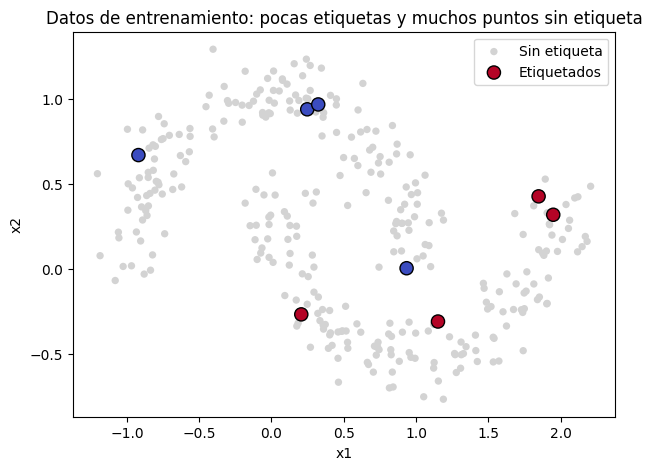

In [3]:
plt.figure(figsize=(7, 5))
plt.scatter(
    X_train[unlabeled_mask, 0],
    X_train[unlabeled_mask, 1],
    c="lightgray",
    s=28,
    label="Sin etiqueta",
    edgecolor="none",
)
plt.scatter(
    X_train[labeled_mask, 0],
    X_train[labeled_mask, 1],
    c=y_train_semi[labeled_mask],
    cmap="coolwarm",
    s=90,
    label="Etiquetados",
    edgecolor="black",
)
plt.title("Datos de entrenamiento: pocas etiquetas y muchos puntos sin etiqueta")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.show()

## 2. Modelos comparados

- **KNN solo con etiquetas reales**: baseline supervisado con apenas 8 ejemplos.
- **LabelPropagation**: propaga etiquetas en un grafo de similitud RBF.
- **LabelSpreading**: variante relacionada con Zhou et al.; mantiene suavidad local,
  pero regulariza para no copiar etiquetas de forma demasiado rigida.

In [4]:
X_labeled = X_train[labeled_mask]
y_labeled = y_train_true[labeled_mask]

models = {
    "KNN_con_pocas_etiquetas": KNeighborsClassifier(n_neighbors=3),
    "LabelPropagation_RBF": LabelPropagation(kernel="rbf", gamma=20, max_iter=1000),
    "LabelSpreading_RBF": LabelSpreading(kernel="rbf", gamma=20, alpha=0.2, max_iter=1000),
}

fitted = {}
metrics = []

for name, model in models.items():
    if name == "KNN_con_pocas_etiquetas":
        model.fit(X_labeled, y_labeled)
    else:
        model.fit(X_train, y_train_semi)
    fitted[name] = model
    pred = model.predict(X_test)
    metrics.append(
        {
            "modelo": name,
            "accuracy_test": accuracy_score(y_test, pred),
            "errores_test": int((pred != y_test).sum()),
        }
    )

results = pd.DataFrame(metrics).sort_values("accuracy_test", ascending=False)
results

,modelo,accuracy_test,errores_test
1,LabelPropagation_RBF,0.994286,1
2,LabelSpreading_RBF,0.988571,2
0,KNN_con_pocas_etiquetas,0.845714,27


In [5]:
best_name = results.iloc[0]["modelo"]
best_model = fitted[best_name]
best_pred = best_model.predict(X_test)

print(f"Mejor modelo: {best_name}")
print("\nMatriz de confusion:")
print(confusion_matrix(y_test, best_pred))
print("\nReporte de clasificacion:")
print(classification_report(y_test, best_pred, digits=3))

Mejor modelo: LabelPropagation_RBF

Matriz de confusion:
[[88  0]
 [ 1 86]]

Reporte de clasificacion:
              precision    recall  f1-score   support

           0      0.989     1.000     0.994        88
           1      1.000     0.989     0.994        87

    accuracy                          0.994       175
   macro avg      0.994     0.994     0.994       175
weighted avg      0.994     0.994     0.994       175



## 3. Etiquetas inferidas

Esta seccion revisa que etiquetas quedaron asignadas a los puntos originalmente
sin etiqueta. Es la parte transductiva: el algoritmo no solo aprende una frontera,
tambien asigna clase a datos sin rotular.

In [6]:
lp_model = fitted["LabelPropagation_RBF"]
propagated_labels = lp_model.transduction_

propagated_summary = pd.crosstab(
    pd.Series(y_train_true[unlabeled_mask], name="clase_real"),
    pd.Series(propagated_labels[unlabeled_mask], name="clase_propagada"),
)
propagated_accuracy = accuracy_score(
    y_train_true[unlabeled_mask],
    propagated_labels[unlabeled_mask],
)

print(f"Accuracy en puntos originalmente sin etiqueta: {propagated_accuracy:.3f}")
propagated_summary

Accuracy en puntos originalmente sin etiqueta: 0.997


clase_propagada,0,1
clase_real,,
0,158,0
1,1,158


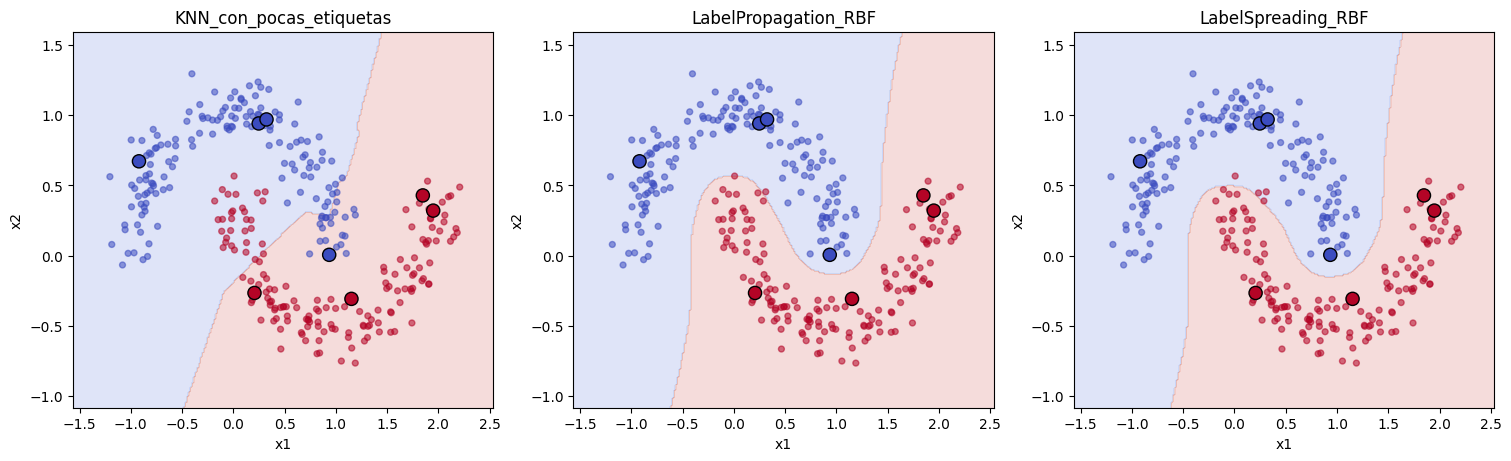

In [7]:
def plot_decision(ax, model, title):
    x_min, x_max = X[:, 0].min() - 0.3, X[:, 0].max() + 0.3
    y_min, y_max = X[:, 1].min() - 0.3, X[:, 1].max() + 0.3
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 250),
        np.linspace(y_min, y_max, 250),
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    zz = model.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, zz, alpha=0.18, cmap="coolwarm")
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train_true, cmap="coolwarm", s=18, alpha=0.55)
    ax.scatter(
        X_train[labeled_mask, 0],
        X_train[labeled_mask, 1],
        c=y_train_true[labeled_mask],
        cmap="coolwarm",
        s=90,
        edgecolor="black",
    )
    ax.set_title(title)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)
for ax, (name, model) in zip(axes, fitted.items()):
    plot_decision(ax, model, name)
plt.show()

## 4. Sensibilidad al grafo

En propagacion de etiquetas el grafo importa. Aqui cambio `gamma`, que controla
cuanto pesa la similitud RBF entre puntos. Valores muy bajos suavizan demasiado;
valores muy altos conectan solo vecinos muy cercanos.

In [8]:
sensitivity_rows = []
for gamma in [1, 5, 10, 20, 35, 60]:
    lp = LabelPropagation(kernel="rbf", gamma=gamma, max_iter=1000)
    lp.fit(X_train, y_train_semi)
    sensitivity_rows.append(
        {
            "gamma": gamma,
            "accuracy_test": accuracy_score(y_test, lp.predict(X_test)),
            "accuracy_propagada_train_unlabeled": accuracy_score(
                y_train_true[unlabeled_mask], lp.transduction_[unlabeled_mask]
            ),
            "iteraciones": lp.n_iter_,
        }
    )

sensitivity = pd.DataFrame(sensitivity_rows)
sensitivity

,gamma,accuracy_test,accuracy_propagada_train_unlabeled,iteraciones
0,1,0.525714,0.517350,253
1,5,0.880000,0.883281,238
2,10,0.937143,0.924290,238
3,20,0.994286,0.996845,327
4,35,1.000000,1.000000,333
5,60,1.000000,1.000000,498


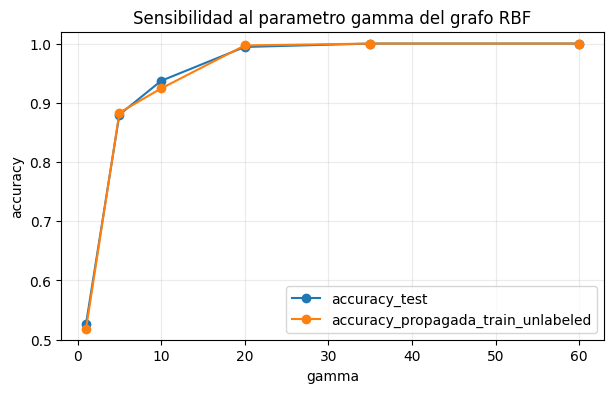

In [9]:
ax = sensitivity.plot(
    x="gamma",
    y=["accuracy_test", "accuracy_propagada_train_unlabeled"],
    marker="o",
    figsize=(7, 4),
)
ax.set_ylim(0.5, 1.02)
ax.set_title("Sensibilidad al parametro gamma del grafo RBF")
ax.set_ylabel("accuracy")
ax.grid(alpha=0.25)
plt.show()

## 5. Hallazgos comparables con las fuentes

1. El uso de datos sin etiqueta mejora frente al baseline con pocas etiquetas.
   Esto coincide con Zhu et al.: si el grafo de similitud captura la estructura,
   los puntos sin etiqueta ayudan a clasificar.
2. LabelSpreading entrega una lectura cercana a Zhou et al.: no solo propaga,
   tambien regulariza la solucion para balancear consistencia local y global.
3. La mejora no es automatica. La encuesta de van Engelen y Hoos enfatiza que
   SSL depende de supuestos sobre la distribucion. En el experimento, cambiar
   `gamma` altera el resultado porque cambia la conectividad efectiva del grafo.